# LabClear Company Harness
An executable demonstration of multiagent orchestration for a Thai health-check assistant.

This notebook runs the real application pipeline with **OFFLINE provider doubles** and synthetic reports. It demonstrates the planner, evidence tools, runtime skills, optional protected analyzer, composer, deterministic checks and reviewer. It does not claim live Thai API or clinical accuracy. Full prompts and observable outputs are shown below; private model reasoning is not collected.

In [1]:
from pathlib import Path
import json, subprocess, sys, hashlib, html
from IPython.display import display, HTML, Image
ROOT = Path.cwd() if (Path.cwd()/"main.py").exists() else Path.cwd().parent
PY = str(ROOT/".venv/bin/python") if (ROOT/".venv/bin/python").exists() else sys.executable
assert (ROOT/"render.yaml").exists()
print("Repository:", ROOT.name)
print("Execution mode: OFFLINE; synthetic data only")

Repository: LabClear
Execution mode: OFFLINE; synthetic data only


## Architecture and contracts
One Render Python service hosts the website and API. Independent local data tools run concurrently. Provider stages follow their evidence dependencies; additional models are enabled only when their role is needed.

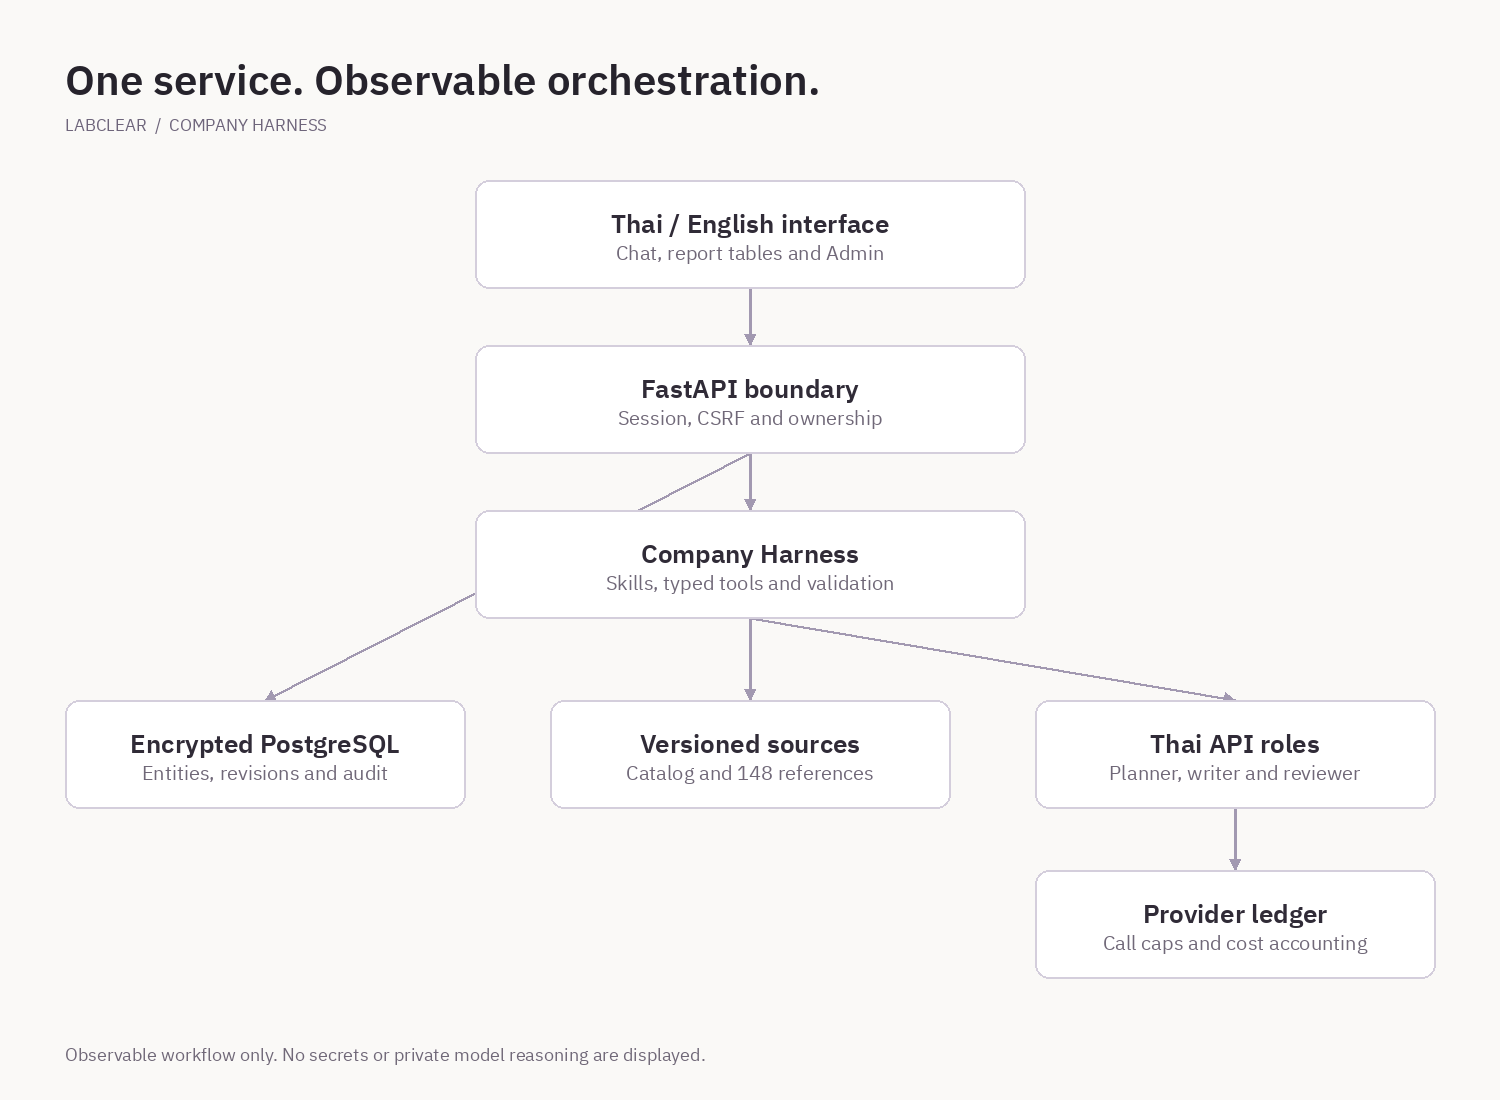

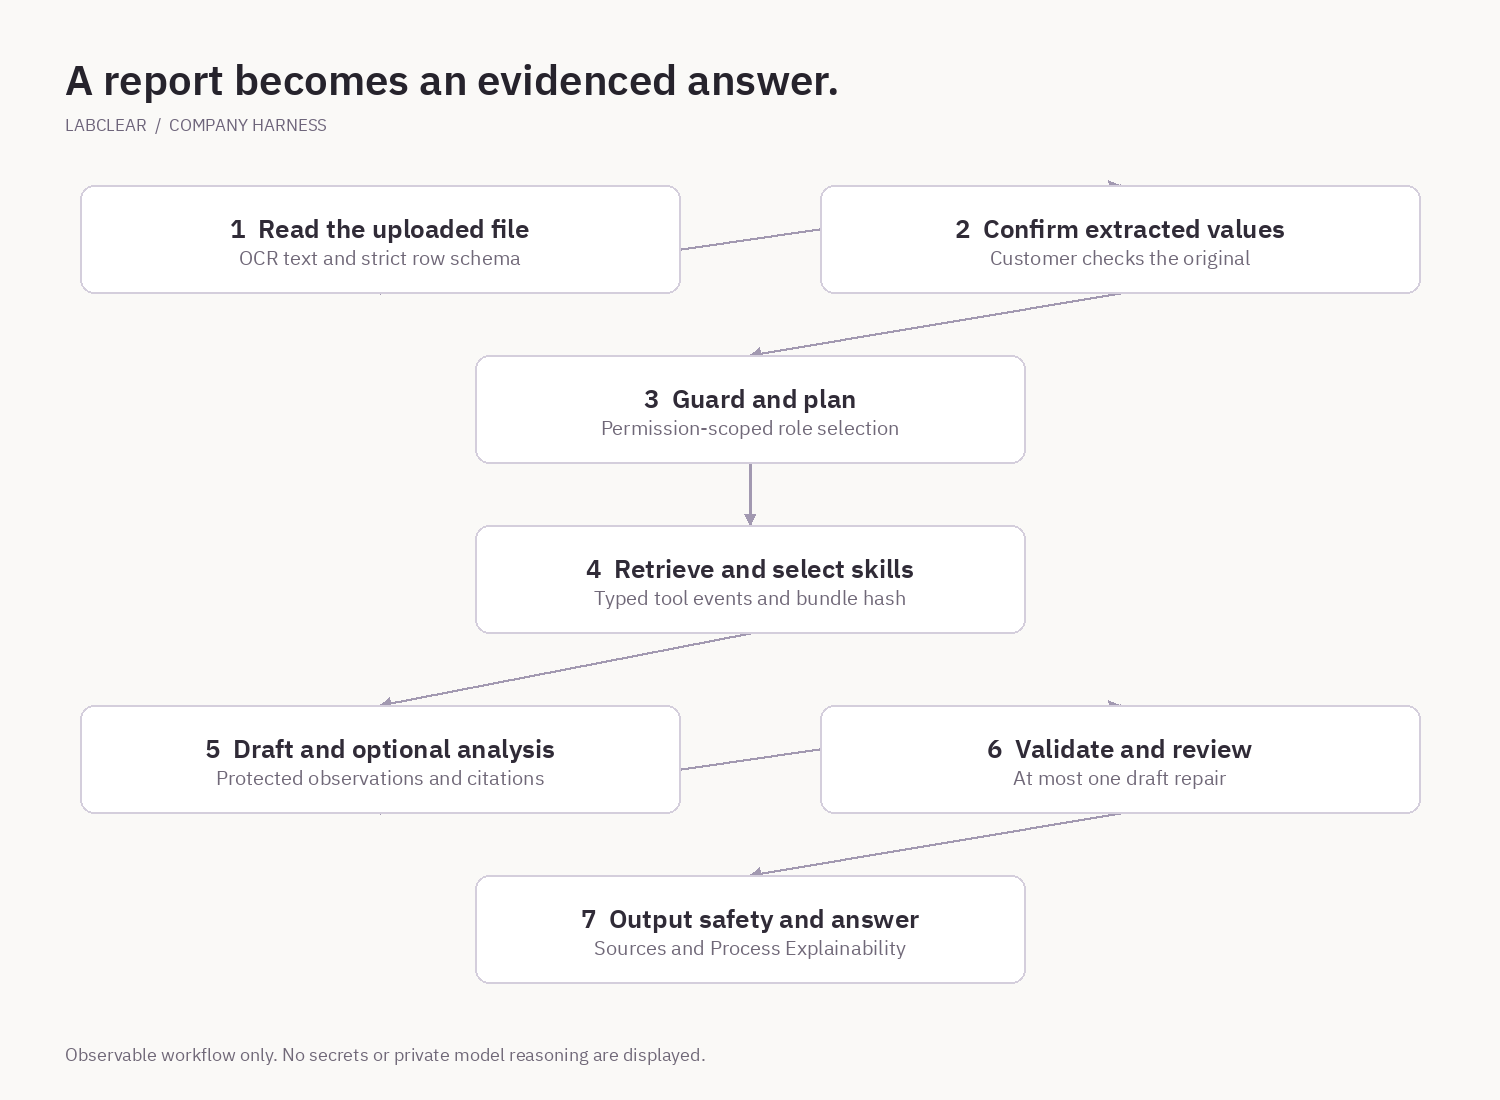

In [2]:
display(Image(filename=str(ROOT/"docs/assets/architecture.png")))
display(Image(filename=str(ROOT/"docs/assets/message-flow.png")))

## Execute a synthetic rollout
The runner denies outbound sockets and injects provider doubles at the transport boundary. The application still applies the real role permissions, typed tools, selected skills, report confirmation and validators. Tesseract supplies raw OCR; errors are retained. No gold rows are sent into the application.

In [3]:
result = subprocess.run([PY, "scripts/demo_harness.py"], cwd=ROOT, text=True, capture_output=True, timeout=180)
assert result.returncode == 0, result.stderr
print(result.stdout)
rollout = json.loads((ROOT/"docs/evidence/current/demo-rollout.json").read_text())
print("Fixture SHA-256:", rollout["fixture_sha256"])
print(rollout["note"])

Recorded 9 observable provider calls to /workspace/scratch/63a651f1f992/LabClear/docs/evidence/current/demo-rollout.json

Fixture SHA-256: 4d24c82a4c0d6700e9e04df86350c9f839f21ecba403c3b9a0dcbcea2e4e735e
Confirmation is simulated as read. OCR mistakes remain visible. Prompts and outputs are observable artifacts, not private model reasoning.


## Observable steps and typed tools
Each event records an operational decision or validation outcome. Durations describe this local offline run only.

In [4]:
for name, turn in rollout["turns"].items():
    if not turn: continue
    print("\nTURN:", name)
    if turn.get("error"): print("ERROR:", turn["error"])
    for event in turn.get("events", []):
        if event.get("type") == "step" and event.get("state") in ("done", "error"):
            print(event.get("id"), "|", event.get("label"), "|", event.get("duration_ms", ""), "ms")
    checks=(turn.get("result") or {}).get("checks", {})
    print(json.dumps({k:checks.get(k) for k in ["harness", "skills", "tools"]}, ensure_ascii=False, indent=2))


TURN: question
harness | Company Harness | 0.0 ms
safety_in | Your message passed the safety check | 8.8 ms
plan | Plan: answer the question, as the Health-check Advisor | 152.6 ms
tool_lookup_packages | Tool: lookup_packages | 0.8 ms
tool_lookup_branches | Tool: lookup_branches | 0.1 ms
tool_lookup_policies | Tool: lookup_policies | 0.1 ms
data | Loaded business data the Health-check Advisor may use | 0.0 ms
tool_retrieve_evidence | Tool: retrieve_evidence | 24.0 ms
search | Found 6 medical sources for "HbA1c" | 24.0 ms
skills | Runtime skills loaded | 0.7 ms
draft | Draft written and checked | 14.7 ms
review | Second review passed | 6.5 ms
safety_out | The answer passed the safety check | 5.6 ms
{
  "harness": {
    "revision": 0,
    "sha256": "0181265c0acfaa58f6943cac06aa50a726f8389242ec8ae9cdbf94cd95cd1445",
    "elapsed_ms": 228
  },
  "skills": {
    "package": "labclear-thai-health-communication 0.3.0-offline",
    "modules": [
      "core",
      "thai-style",
      "evidence

## Full prompts and observable outputs
Expand any role to inspect its exact synthetic input and returned artifact. Image bytes are represented by the fixture hash, avoiding unnecessary base64 output. Production prompts and credentials are never logged by this demonstration.

In [5]:
for i, call in enumerate(rollout["prompts"], 1):
    content=json.dumps(call, ensure_ascii=False, indent=2)
    display(HTML("<details><summary><b>"+str(i)+" · "+html.escape(call["stage"])+" · "+html.escape(call["model"])+"</b></summary><pre style='white-space:pre-wrap;max-height:600px;overflow:auto'>"+html.escape(content)+"</pre></details>"))

## Deterministic benchmark results
The original coursework suite and the uploaded-file suite are separate. A, B and C are descriptive runs with source provenance; their aggregate offline scores do not establish model improvement. Every failure remains visible.

In [6]:
comparison=json.loads((ROOT/"docs/evidence/current/comparison.json").read_text())
for row in comparison: print(row)
run=ROOT/"docs/evidence/current/owner-ocr-C"
one=subprocess.check_output([PY,"scripts/score_benchmark.py",str(run)],cwd=ROOT)
two=subprocess.check_output([PY,"scripts/score_benchmark.py",str(run)],cwd=ROOT)
assert one == two
score=json.loads(one)
print("Deterministic output: byte-identical")
print("Score digest:", score["score_sha256"])
print(json.dumps(score["ocr"],indent=2))

{'run': 'owner-coursework-A', 'mode': 'OFFLINE', 'profile': 'A', 'planned': 20, 'pass': 15, 'score': 75.0, 'ocr_exact': 88, 'ocr_expected': 93, 'requests': 115}
{'run': 'owner-coursework-B2', 'mode': 'OFFLINE', 'profile': 'B', 'planned': 20, 'pass': 15, 'score': 75.0, 'ocr_exact': 88, 'ocr_expected': 93, 'requests': 115}
{'run': 'owner-coursework-C', 'mode': 'OFFLINE', 'profile': 'C', 'planned': 20, 'pass': 15, 'score': 75.0, 'ocr_exact': 88, 'ocr_expected': 93, 'requests': 120}
{'run': 'owner-ocr-C', 'mode': 'OFFLINE', 'profile': 'C', 'planned': 12, 'pass': 0, 'score': 0.0, 'ocr_exact': 217, 'ocr_expected': 252, 'requests': 120}
Deterministic output: byte-identical
Score digest: 795ad3fb33f9ac4cdcc6e7b4a9d56a61d0058fd98de9b86a2116c96e4cc59880
{
  "duplicate_rows": 2,
  "expected_rows": 252,
  "extra_rows": 14,
  "flags_exact": 216,
  "flags_exact_percent": 85.7143,
  "references_exact": 182,
  "references_exact_percent": 72.2222,
  "rows_found": 226,
  "units_exact": 145,
  "units_exa

## Review the uploaded images and PDFs
The PNGs below are the exact owner uploads. The six PDFs match the original synthetic report PDFs byte for byte. The full input manifest is validated before a benchmark run.

O01-PNG 01_A_Liver.png 414394 bytes
O01-PDF 01_A_Liver.pdf 37638 bytes
O02-PNG 02_A_Renal.png 418971 bytes
O02-PDF 02_A_Renal.pdf 39090 bytes
O03-PNG 03_B_Lipid.png 442895 bytes
O03-PDF 03_B_Lipid.pdf 33834 bytes
O04-PNG 04_B_Glucose_Urine.png 426813 bytes
O04-PDF 04_B_Glucose_Urine.pdf 34104 bytes
O05-PNG 05_C_Hematology.png 604163 bytes
O05-PDF 05_C_Hematology.pdf 42697 bytes
O06-PNG 06_C_Thyroid.png 601661 bytes
O06-PDF 06_C_Thyroid.pdf 42802 bytes


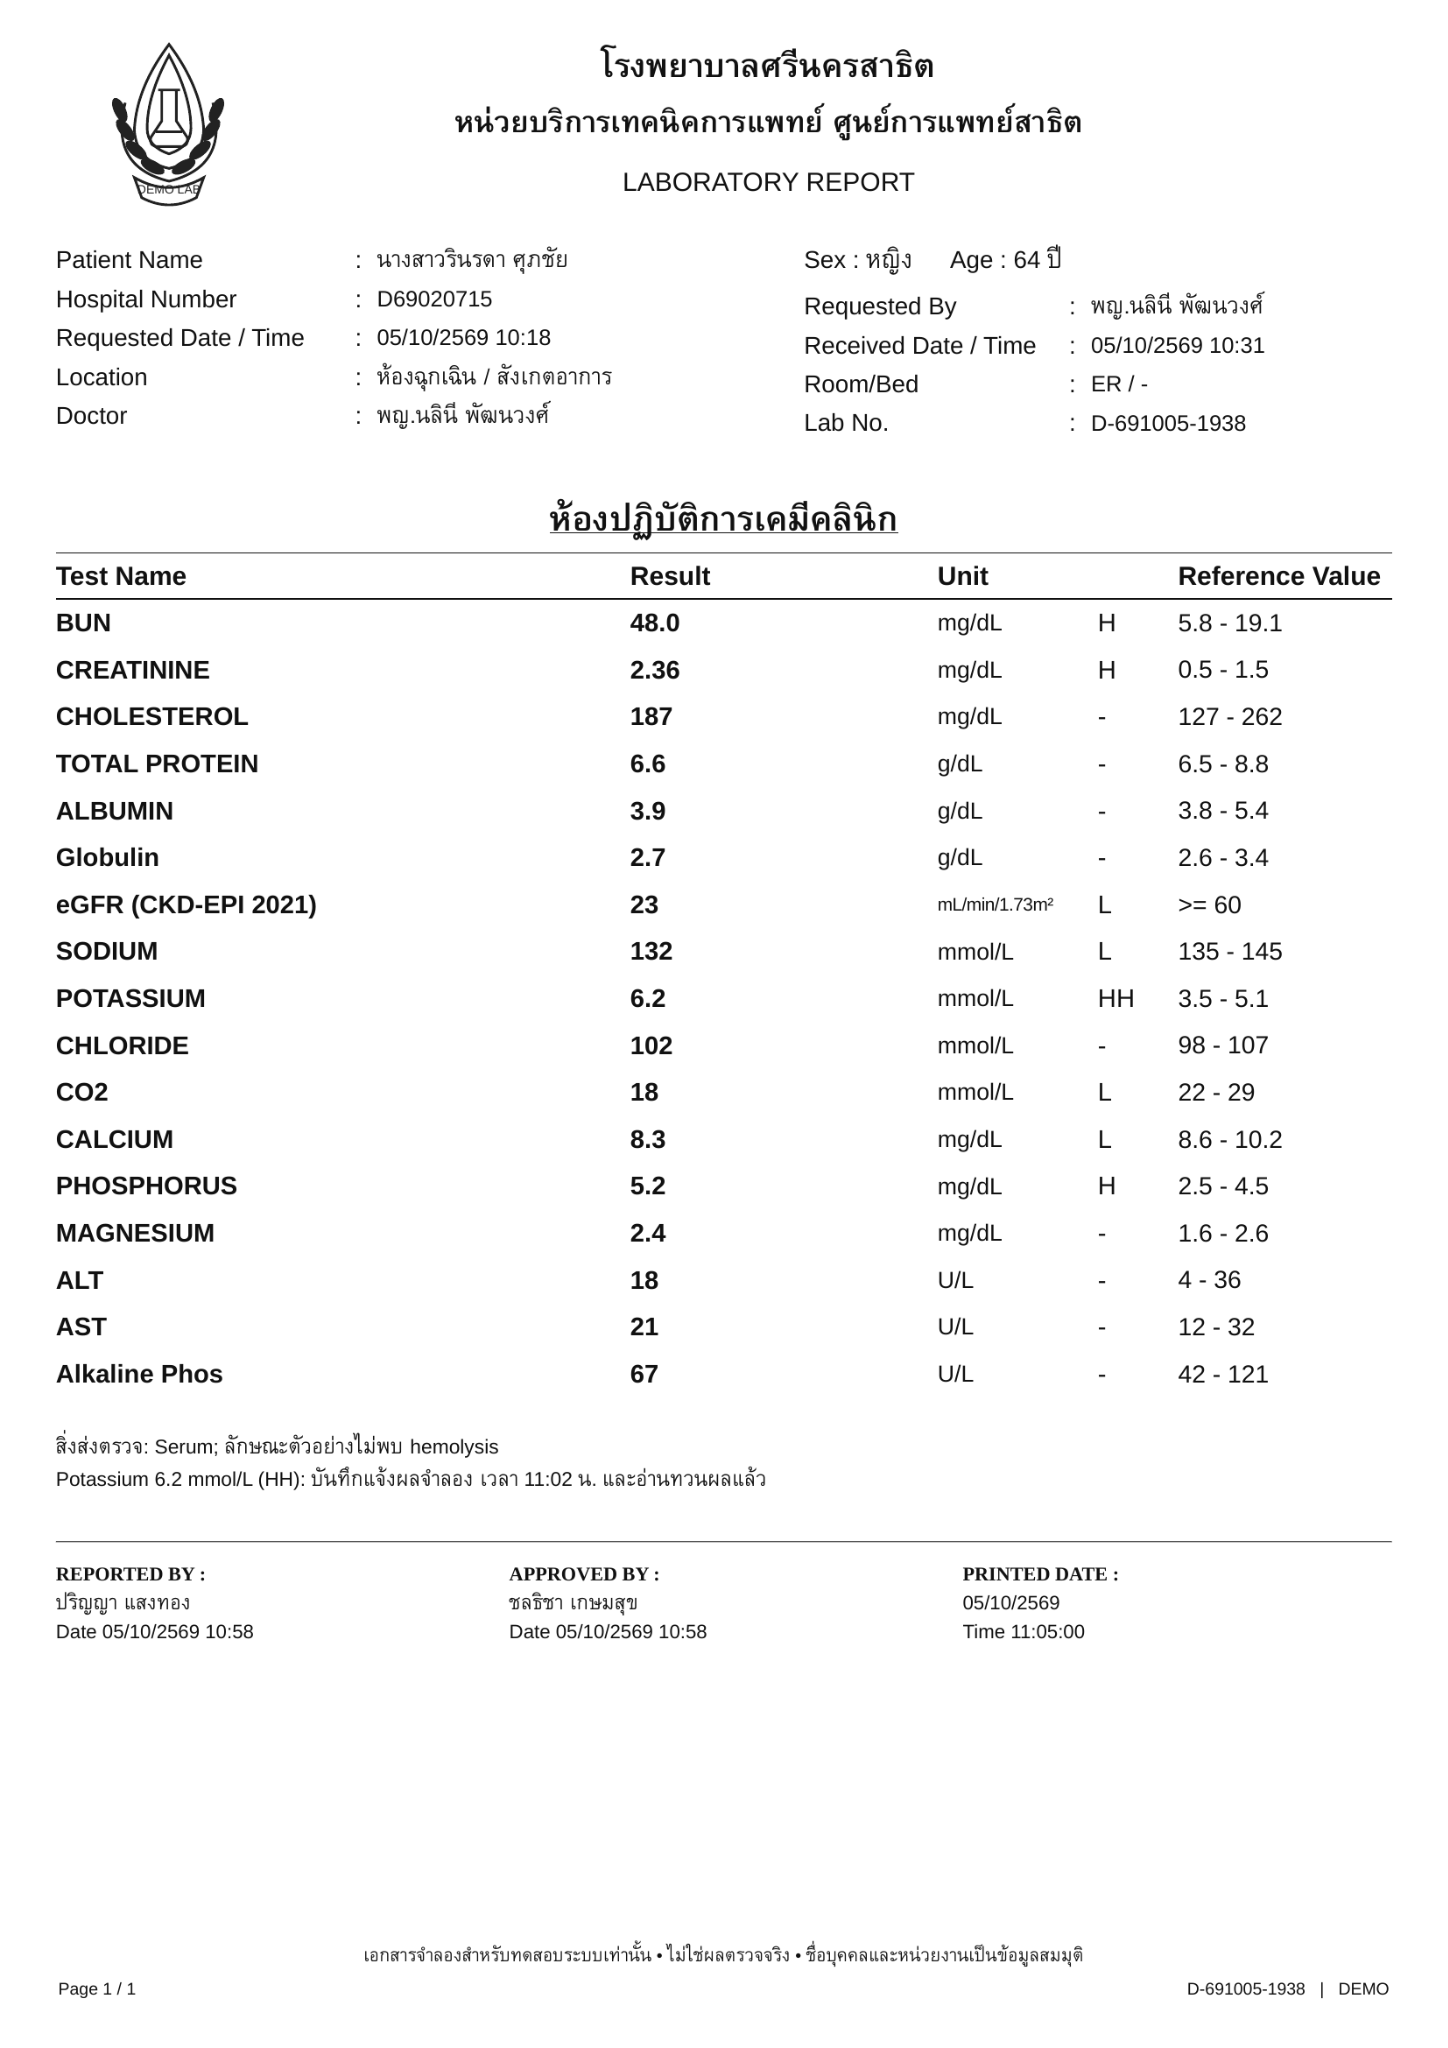

In [7]:
dataset=json.loads((ROOT/"eval/ocr_files/dataset.json").read_text())
for case in dataset["cases"]:
    path=ROOT/case["image"]
    assert hashlib.sha256(path.read_bytes()).hexdigest() == case["image_sha256"]
    print(case["id"], path.name, path.stat().st_size, "bytes")
display(Image(filename=str(ROOT/"examples/ocr_owner_20261009/png/02_A_Renal.png"),width=500))

## Run with actual Thai APIs
Use `scripts/benchmark_labclear.py preflight` with an account-specific verified free policy, then run `--mode live-free` on synthetic data. Secrets belong in the trial environment, never this notebook. Start with the smoke suite, respect the shared ledger and quota, and retain every attempt.

A connectivity test checks one response format. A live benchmark measures the configured model pipeline. Clinical entailment and Thai readability require separate human review. No new live benchmark was available for the recorded release.